In [1]:
import pandas as pd
import numpy as np
import sklearn

In [2]:
df = pd.read_csv("../../data/data_transformed_main.csv").set_index(["ID на сайте", "Источник"])

In [3]:
df.head()

,,Цена,Дата,Тип автора,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь,Цена / м2,Москва?
ID на сайте,Источник,,,,,,,,,,,,,,,,,,
321970859,cian.ru,34500.0,2025-12-17 08:36:40,Агентство,Химки,Беломорская,"Рабочая ул., 2","НАЗВАНИЕ: Офис в Московская область, Химки Раб...",55.908036,37.432951,https://www.cian.ru/rent/commercial/321970859,https://images.cdn-cian.ru/images/2633983674-1...,9.167,4.0,4.0,Офис / Здание,23.0,1500.0,0.0
323570959,cian.ru,160500.0,2025-12-17 08:36:40,Частное лицо,Солнечногорск городской округ,Зеленоград — Крюково,21А,НАЗВАНИЕ: Торговая площадь в Московская област...,55.972650,37.099604,https://www.cian.ru/rent/commercial/323570959,https://images.cdn-cian.ru/images/torgovoe-pom...,9.167,1.0,1.0,Торговое / свободного вида,107.0,1500.0,0.0
319937619,cian.ru,1226740.0,2025-12-17 08:36:40,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319937619,https://images.cdn-cian.ru/images/2634163777-1...,9.167,2.0,6.0,Офис / Здание,830.0,1478.0,0.0
319936797,cian.ru,236480.0,2025-12-17 08:36:39,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319936797,https://images.cdn-cian.ru/images/2634163921-1...,9.167,2.0,6.0,Офис / Здание,160.0,1478.0,0.0
319938233,cian.ru,1537120.0,2025-12-17 08:36:38,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319938233,https://images.cdn-cian.ru/images/2569099478-1...,9.167,2.0,6.0,Офис / Здание,1040.0,1478.0,0.0


In [20]:
df["Описание"] = df["Описание"].str.lower()
df["Описание"] = df["Описание"].fillna("")
ru_eng = {
    'a' : 'а',
    'b' : 'в',
    'e' : 'е',
    'k' : 'к',
    'm' : 'м',
    'h' : 'н',
    'o' : 'о',
    'p' : 'р', 
    'c' : 'с',
    't' : 'т',
    'y' : 'у',
    'x' : 'х' 
}


(True, True)

In [5]:
def f(text):
    ans = ""
    for c in text:
        if (c in ru_eng):
            c = ru_eng[c]
        ans += c
    return ans
df["Описание"] = df["Описание"].apply(lambda text: f(text))

In [6]:
from collections import Counter
import string
import re

In [7]:
%%time
trans_table = str.maketrans({ch: ' ' for ch in (string.punctuation + string.digits)})
word_counts = Counter()
for t in df["Описание"].dropna():
    t = t.translate(trans_table)
    t = re.sub(r'\s+', ' ', t).strip()
    words = re.findall(r'\b\w+\b', t)
    word_counts.update(words)
word_counts = {w: c for w, c in word_counts.items() if (c > 3 and len(w) > 2)}
c = Counter(word_counts)
for w, _ in c.most_common(10):
    del word_counts[w]

CPU times: total: 4.27 s
Wall time: 4.75 s


In [8]:
!pip install nltk

In [9]:
%%time
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('russian'))

word_counts = {
    w: c for w, c in word_counts.items()
    if w not in stop_words
}

CPU times: total: 328 ms
Wall time: 1.14 s


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\timof\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
!pip install pymorphy2

In [11]:
import pymorphy2

morph = pymorphy2.MorphAnalyzer()

lemma_words = {}
for w in word_counts:
    lemma_words[w] = morph.parse(w)[0].normal_form

C:\Users\timof\miniconda3\envs\sirius\lib\site-packages\pymorphy2\analyzer.py:114: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [12]:
def process_text(t):
    if not isinstance(t, str):
        return ""
    words = re.findall(r'\b\w+\b', t)
    res = []
    for w in words:
        if w in lemma_words:
            res.append(lemma_words[w])
    return " ".join(res)

In [13]:
%%time
df["Описание2"] = (df["Описание"].apply(process_text))

CPU times: total: 1.84 s
Wall time: 2.09 s


In [14]:
sorted_lemma_words = dict(sorted(lemma_words.items(), key=lambda x: x[0]))
for word, lemma in sorted_lemma_words.items():
    print(lemma)

ddх
disратсна
disсоvеr
dns
dаil
dаrкsтоr
dесоr
dоdый
dоlс
fiт
fiтnеss
fiх
fiхрriс
frеnсна
fr
fuтur
fамili
fастоr
fоr
fооd
fотоn
gis
glоri
grееn
grееnwооd
grееnроinт
grоuр
gас
gата
gва
gоld
iii
indusтriаl
indusтriеs
indех
insтrеть
inтеrмаrк
isраса
iснild
jungl
jас
jеаns
jокi
jоуа
lif
ligнт
lill
liv
luхur
lаnd
lав
lамоd
lеd
lеvеl
lееd
lоfт
lоfтадрес
lоss
lоung
lоv
lоокий
lот
lрg
null
nаil
nет
nетоn
nоrd
quаdrоом
quот
rig
rigаlаnd
rinть
rivеr
russi
ruмi
rаilwау
rаl
rас
rеfоrм
rеаl
rер
rесертiоn
rетаil
rоsтiс
rоsтiсs
rомаns
rоом
siемеns
siмоn
slаv
suiт
sunligнт
susнi
sаn
sвr
sкоlкоvый
sку
sмаrт
sнin
sнеll
sнеllсоr
sнеrlаnd
sнора
sокоlоv
sрuтniк
sра
sраса
sснindlеr
sтrеть
sтаff
sтоr
viillаg
villаg
vivый
viеw
viр
viт
vnuкоvый
vrv
vеrуfооd
wifi
wildвеrriеs
wilвеrriеs
wiтн
wеllnеss
wеllмакs
wеllтоn
wеsт
wеsтеаsт
wнiт
wнатsарра
wоrld
wоrldgум
wоrк
wок
zаrin
zамания
zерреlin
zоll
zоомliоn
аllвn
аlко
аnd
аrеа
аrт
аsкоn
аsтоriуа
аuтоgrарн
аviтый
аwаrds
аббакумов
абель
абк
абрамцевый
абсолют
абсолю

In [15]:
for t in df["Описание2"].head(5):
    print(t)

химки рабочий лот предложение собственник предлагаться аренда офисный блок современный деловой центр иметь качественный современный оформление готовый немедленный занятие инфраструктура здание включать круглосуточный служба охрана система видеонаблюдение обеспечивать высокий уровень безопасность ваш удобство комфорт ваш клиент сотрудник территория организовать больший парковочный площадка арендовать помещение предоставляться возможность использование юридический адрес актуальный площадь цена год цена включить затрата электричество коммунальный расход ндс обеспечительный платёж месяц получить подробный презентация планировка фотография звонить отправить свой емаil номер телефон сообщение портал высылать течение минута запрос конт лицо оксана доб лот
торговый площадь солнечногорск городской округ пос жилино аренда собственник предлагать аренда современный торговый центр расположить въезд голубой первый зеленоградский самый густонаселённый район подмосковье окружение свыше новый многоквар

In [16]:
df.head()

,,Цена,Дата,Тип автора,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь,Цена / м2,Москва?,Описание2
ID на сайте,Источник,,,,,,,,,,,,,,,,,,,
321970859,cian.ru,34500.0,2025-12-17 08:36:40,Агентство,Химки,Беломорская,"Рабочая ул., 2","название: офис в московская область, химки раб...",55.908036,37.432951,https://www.cian.ru/rent/commercial/321970859,https://images.cdn-cian.ru/images/2633983674-1...,9.167,4.0,4.0,Офис / Здание,23.0,1500.0,0.0,химки рабочий лот предложение собственник пред...
323570959,cian.ru,160500.0,2025-12-17 08:36:40,Частное лицо,Солнечногорск городской округ,Зеленоград — Крюково,21А,название: торговая площадь в московская област...,55.972650,37.099604,https://www.cian.ru/rent/commercial/323570959,https://images.cdn-cian.ru/images/torgovoe-pom...,9.167,1.0,1.0,Торговое / свободного вида,107.0,1500.0,0.0,торговый площадь солнечногорск городской округ...
319937619,cian.ru,1226740.0,2025-12-17 08:36:40,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","название: офис в московская область, мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319937619,https://images.cdn-cian.ru/images/2634163777-1...,9.167,2.0,6.0,Офис / Здание,830.0,1478.0,0.0,мытищи колпаков лот предложение собственник сд...
319936797,cian.ru,236480.0,2025-12-17 08:36:39,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","название: офис в московская область, мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319936797,https://images.cdn-cian.ru/images/2634163921-1...,9.167,2.0,6.0,Офис / Здание,160.0,1478.0,0.0,мытищи колпаков лот предложение собственник сд...
319938233,cian.ru,1537120.0,2025-12-17 08:36:38,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","название: офис в московская область, мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319938233,https://images.cdn-cian.ru/images/2569099478-1...,9.167,2.0,6.0,Офис / Здание,1040.0,1478.0,0.0,мытищи колпаков лот предложение собственник сд...


In [17]:
!pip install wordcloud
!pip install metrics

cluster: 1; samples: 151


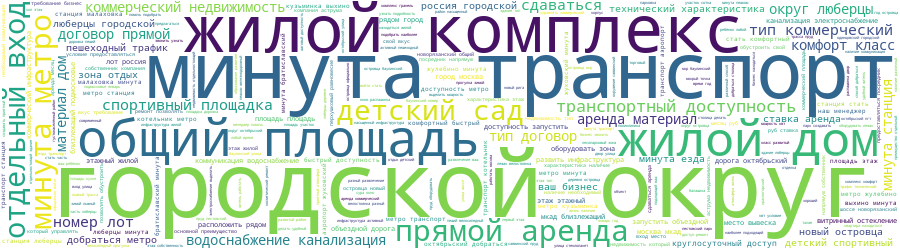

cluster: 2; samples: 214


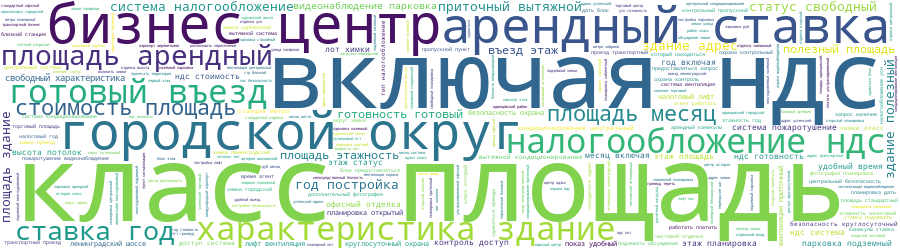

cluster: 3; samples: 141


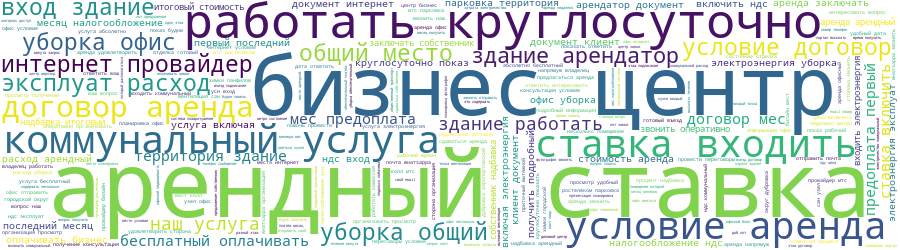

cluster: 4; samples: 43


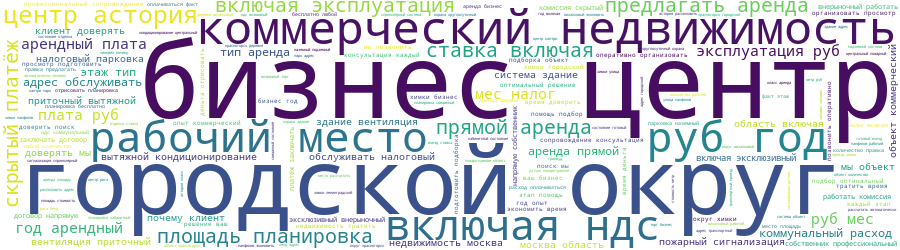

cluster: 5; samples: 451


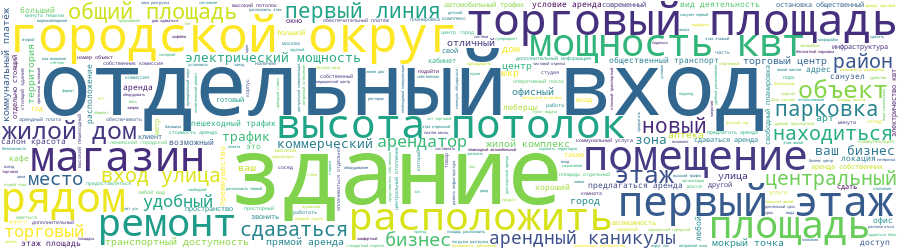

In [18]:
from sklearn.decomposition import LatentDirichletAllocation
from visualization import draw_wordcloud, draw_cluster_clouds
from sklearn.feature_extraction.text import CountVectorizer

test = df.head(1000).copy()
test["Описание2"] = test["Описание2"].fillna("")
tf_vectorizer = CountVectorizer(max_features=1000).fit(test['Описание2'])
bow = tf_vectorizer.transform(test['Описание2'])

n_components = 5
lda = LatentDirichletAllocation(
    n_components=n_components, 
    random_state=42,
    learning_method='online'
)
lda.fit(bow)

labels_lda = np.argmax(lda.transform(bow), axis=1)
n_clusters = n_components
cloud_kwargs = { 'max_words':3000, 'width':900, 'height':250 }
draw_cluster_clouds(test, labels_lda, n_clusters, alert_by='Описание2', cloud_kwargs=cloud_kwargs)